# Comparison of tree-based methods (Fig. 3)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
from pathlib import Path

try:
    import scienceplots
    plt.style.use('science')
except Exception:
    pass


In [2]:
def plot_results_clean_legend_optimal(df, colors, metric='accuracy', figsize=(12, 6), legend_loc="best", linewidth=2.5, y_range=(0.69, 0.905), major_ticks_params_x=(2,6,2), minor_ticks_params_x=(1,7,2), major_ticks_params_y=(0.5, 1.05, 0.05), minor_ticks_params_y=(0.5, 1.05, 0.01), bbox_to_anchor_method = (0.5, 0.5), bbox_to_anchor_split = (0.5, 0.5)):
   
    plt.figure(figsize=figsize)

    plt.rcParams['axes.labelsize'] = 30
    plt.rcParams['axes.titlesize'] = 25
    plt.rcParams['xtick.labelsize'] = 25
    plt.rcParams['ytick.labelsize'] = 25
    plt.rcParams['legend.fontsize'] = 25
    legend_item_fontsize = plt.rcParams['legend.fontsize'] * 0.9

    g1 = sns.lineplot(
        data=df[df['isTrain'] == True],
        x='depth',
        y=metric,
        hue='method',
        ci=95,
        palette=colors,
        linewidth=linewidth,
        markersize=10,
        zorder=2,
        alpha=1,
    )
    if g1.get_legend() is not None:
        g1.get_legend().remove()

    g2 = sns.lineplot(
        data=df[df['isTrain'] == False],
        x='depth',
        y=metric,
        hue='method',
        ci=95,
        linestyle='--',
        palette=colors,
        linewidth=linewidth,
        markersize=10,
        alpha=1,
    )
    if g2.get_legend() is not None:
        g2.get_legend().remove()

    all_methods_in_df = df['method'].unique()
    desired_order_keys = ['DEFT', 'CART', 'OC1', '2-mer']

    ordered_method_names = [m for m in desired_order_keys if m in all_methods_in_df]
    for m_df in all_methods_in_df:
        if m_df not in ordered_method_names:
            ordered_method_names.append(m_df)

    method_handles = []
    for method_name in ordered_method_names:
        if method_name in colors:
            handle = mlines.Line2D(
                [], [],
                color=colors[method_name],
                marker='o',
                linestyle='None',
                markersize=8,
                label=method_name,
            )
            method_handles.append(handle)

    method_legend = plt.legend(
        handles=method_handles,
        fontsize=legend_item_fontsize,
        loc=legend_loc,
        bbox_to_anchor=bbox_to_anchor_method,
        labelspacing=0.1,
    )
    plt.gca().add_artist(method_legend)

    linestyle_handles = [
        mlines.Line2D([], [], color='dimgray', linestyle='-', linewidth=linewidth, label='Train'),
        mlines.Line2D([], [], color='dimgray', linestyle='--', linewidth=linewidth, label='Test'),
    ]

    plt.legend(
        handles=linestyle_handles,
        handlelength=1.5,
        fontsize=legend_item_fontsize,
        loc=legend_loc,
        bbox_to_anchor=bbox_to_anchor_split,
        labelspacing=0.4,
    )

    major_ticks = np.arange(major_ticks_params_x[0], major_ticks_params_x[1], major_ticks_params_x[2])
    minor_ticks = np.arange(minor_ticks_params_x[0], minor_ticks_params_x[1], minor_ticks_params_x[2])
    plt.gca().set_xticks(major_ticks)
    plt.gca().set_xticks(minor_ticks, minor=True)
    plt.xlim(1, 6)

    major_ticks_y = np.arange(major_ticks_params_y[0], major_ticks_params_y[1], major_ticks_params_y[2])
    minor_ticks_y = np.arange(minor_ticks_params_y[0], minor_ticks_params_y[1], minor_ticks_params_y[2])
    plt.gca().set_yticks(major_ticks_y)
    plt.gca().set_yticks(minor_ticks_y, minor=True)
    plt.ylim(y_range[0], y_range[1])

    plt.xlabel('Depth')
    plt.ylabel(metric.capitalize())
    plt.tight_layout()
    return plt.gcf()


In [3]:
def _find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'conf').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current working directory.')

ROOT = _find_repo_root()
RESULTS_ROOT = ROOT / 'results'
FIGURES_ROOT = ROOT / 'figures' / 'fig3'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

DATASETS = ['polymerase', 'mpra_enhancers', 'promoters']

DEFT_PATHS = {
    'polymerase': RESULTS_ROOT / 'polymerase' / 'results_deft_multiple_seeds.csv',
    'mpra_enhancers': RESULTS_ROOT / 'mpra_enhancers' / 'results_deft_multiple_seeds.csv',
    'promoters': RESULTS_ROOT / 'promoters' / 'results_deft_multiple_seeds.csv',
}

BASELINE_FILES = {
    'cart_identity': 'cart__identity.csv',
    'oc1_identity': 'oc1__identity.csv',
    'cart_k2': 'cart__kmer_count__k2.csv',
}

METHOD_LABELS = {
    'deft': 'DEFT',
    'cart_identity': 'CART',
    'oc1_identity': 'OC1',
    'cart_k2': '2-mer',
}

DEFT_METHOD_ALIASES = {'original', 'DEFT', 'enhancer_classification_seeds'}

COLORS = {
    'DEFT': '#3366CC',
    'CART': '#FFA500',
    '2-mer': '#FF5733',
    'OC1': '#2CA02C',
}


def _normalize_baseline_df(df, method_label):
    out = df.copy()
    out = out[out['sweep_param'].astype(str) == 'max_depth'].copy()
    out['depth'] = out['sweep_value'].astype(int)
    out['isTrain'] = out['split'].astype(str).str.lower().eq('train')
    out['method'] = method_label
    out['random_seed'] = out['seed'].astype(int)
    return out[['depth', 'accuracy', 'auprc', 'f1', 'precision', 'recall', 'isTrain', 'method', 'random_seed']]


def load_unified_tree_baselines(dataset):
    base_dir = RESULTS_ROOT / dataset / 'baselines'

    df_cart = pd.read_csv(base_dir / BASELINE_FILES['cart_identity'])
    df_oc1 = pd.read_csv(base_dir / BASELINE_FILES['oc1_identity'])
    df_k2 = pd.read_csv(base_dir / BASELINE_FILES['cart_k2'])

    return pd.concat([
        _normalize_baseline_df(df_cart, METHOD_LABELS['cart_identity']),
        _normalize_baseline_df(df_oc1, METHOD_LABELS['oc1_identity']),
        _normalize_baseline_df(df_k2, METHOD_LABELS['cart_k2']),
    ], ignore_index=True)


def load_deft(dataset):
    df = pd.read_csv(DEFT_PATHS[dataset]).copy()
    df['depth'] = df['depth'].astype(int)
    df['isTrain'] = df['isTrain'].astype(bool)
    df['method'] = df['method'].where(~df['method'].astype(str).isin(DEFT_METHOD_ALIASES), METHOD_LABELS['deft'])
    df['method'] = METHOD_LABELS['deft']
    return df[['depth', 'accuracy', 'auprc', 'f1', 'precision', 'recall', 'isTrain', 'method', 'random_seed']]


def build_plot_df(dataset, max_depth=6):
    df = pd.concat([load_deft(dataset), load_unified_tree_baselines(dataset)], ignore_index=True)
    df = df[df['depth'] <= max_depth].copy()
    return df


/tmp/ipykernel_915841/3402925312.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g1 = sns.lineplot(
/tmp/ipykernel_915841/3402925312.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g2 = sns.lineplot(


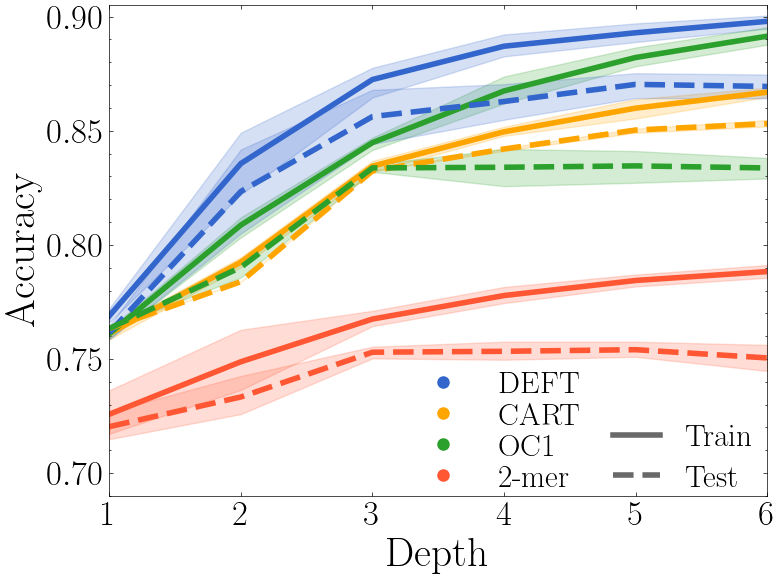

PosixPath('/home/nvth2/deft_cr/figures/fig3/polymerase_accuracy_unified_baselines.pdf')

In [4]:
# Polymerase
poly_df = build_plot_df('polymerase', max_depth=6)

bbox_to_anchor_method = (0.76, -0.05)
bbox_to_anchor_split = (1.02, -0.05)

fig = plot_results_clean_legend_optimal(
    poly_df,
    metric='accuracy',
    figsize=(8, 6),
    colors=COLORS,
    linewidth=4,
    major_ticks_params_x=(1, 7, 1),
    minor_ticks_params_x=(1, 7, 2),
    y_range=(0.69, 0.905),
    legend_loc='lower right',
    bbox_to_anchor_method=bbox_to_anchor_method,
    bbox_to_anchor_split=bbox_to_anchor_split,
)

out = FIGURES_ROOT / 'polymerase_accuracy_unified_baselines.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
out


/tmp/ipykernel_915841/3402925312.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g1 = sns.lineplot(
/tmp/ipykernel_915841/3402925312.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g2 = sns.lineplot(


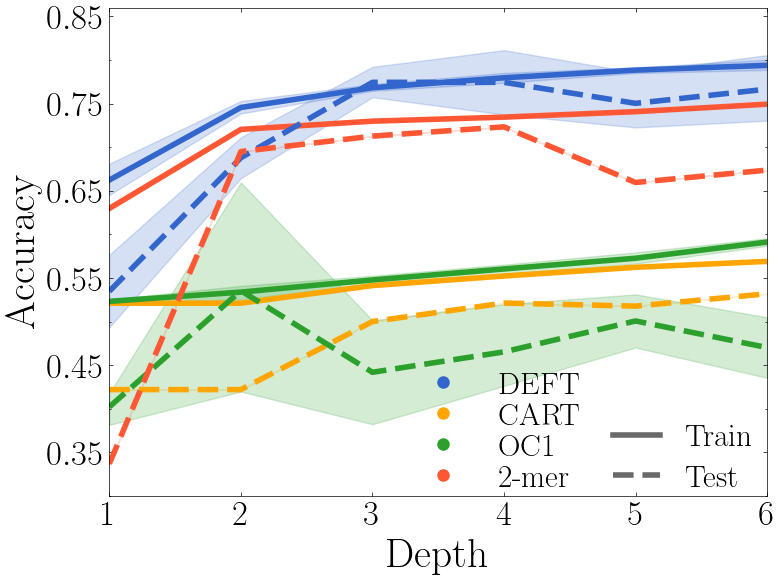

PosixPath('/home/nvth2/deft_cr/figures/fig3/mpra_enhancers_accuracy_unified_baselines.pdf')

In [5]:
# MPRA enhancers
mpra_df = build_plot_df('mpra_enhancers', max_depth=6)

bbox_to_anchor_method = (0.76, -0.05)
bbox_to_anchor_split = (1.02, -0.05)

fig = plot_results_clean_legend_optimal(
    mpra_df,
    metric='accuracy',
    figsize=(8, 6),
    colors=COLORS,
    linewidth=4,
    y_range=(0.3, 0.86),
    major_ticks_params_x=(1, 7, 1),
    minor_ticks_params_x=(1, 7, 2),
    major_ticks_params_y=(0.35, 0.86, 0.1),
    minor_ticks_params_y=(0.3, 0.85, 0.05),
    legend_loc='lower right',
    bbox_to_anchor_method=bbox_to_anchor_method,
    bbox_to_anchor_split=bbox_to_anchor_split,
)

out = FIGURES_ROOT / 'mpra_enhancers_accuracy_unified_baselines.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
out


/tmp/ipykernel_915841/3402925312.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g1 = sns.lineplot(
/tmp/ipykernel_915841/3402925312.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g2 = sns.lineplot(


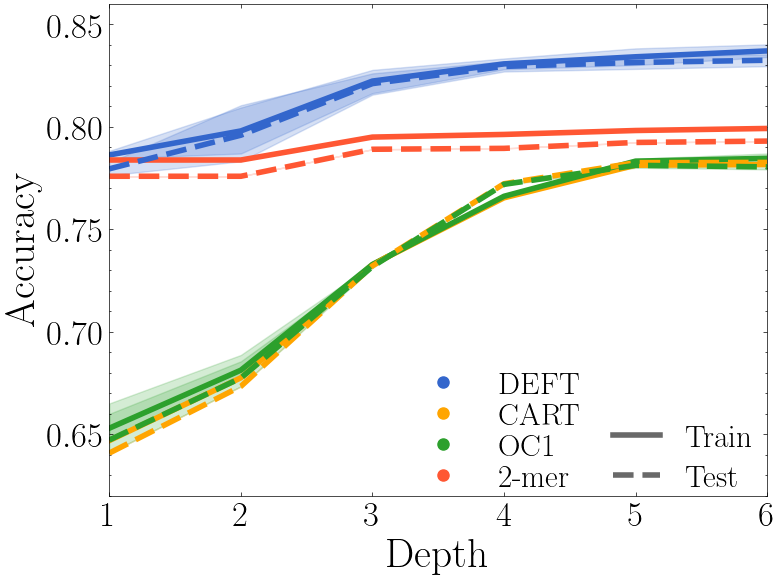

PosixPath('/home/nvth2/deft_cr/figures/fig3/promoters_accuracy_unified_baselines.pdf')

In [6]:
# Promoters
prom_df = build_plot_df('promoters', max_depth=6)

bbox_to_anchor_method = (0.76, -0.05)
bbox_to_anchor_split = (1.02, -0.05)

fig = plot_results_clean_legend_optimal(
    prom_df,
    metric='accuracy',
    figsize=(8, 6),
    colors=COLORS,
    linewidth=4,
    y_range=(0.62, 0.86),
    major_ticks_params_x=(1, 7, 1),
    minor_ticks_params_x=(1, 7, 2),
    major_ticks_params_y=(0.35, 0.86, 0.05),
    minor_ticks_params_y=(0.3, 0.85, 0.01),
    legend_loc='lower right',
    bbox_to_anchor_method=bbox_to_anchor_method,
    bbox_to_anchor_split=bbox_to_anchor_split,
)

out = FIGURES_ROOT / 'promoters_accuracy_unified_baselines.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
out
